<a href="https://colab.research.google.com/github/igupansini/utfpr-AI/blob/main/CEIA-POSIA05/PerceptronSklearnBancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Perceptron Simples com Sklearn aplicado ao Dataset Bancário

In [27]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
df = pd.read_csv("/content/drive/MyDrive/UTFPR_IA/bancario.csv")

df.head()

,Conta,Renda,Dívida,Classe
0,101,2800,550,bom
1,102,1300,500,mau
2,103,1400,80,bom
3,104,500,200,mau
4,105,1100,270,mau


In [29]:
# separando a coluna da classe (Classe: 'bom' ou 'mau') de todas as amostras do dataset
y = df.iloc[:, 3].values

# substituindo o valor string em numérico, baseado no que determina a função de ativação
y = np.where(y == 'mau', -1, 1)

# separando as colunas com as variáveis (Renda e Dívida) para determinar os inputs da RNA
X = df.iloc[:, [1, 2]].values

print(y.shape)
print(X.shape)

(21,)
(21, 2)


In [30]:
# normalização dos dados sklearn - dados entre 0 e 1
scaler = preprocessing.MinMaxScaler()
X = scaler.fit_transform(X)

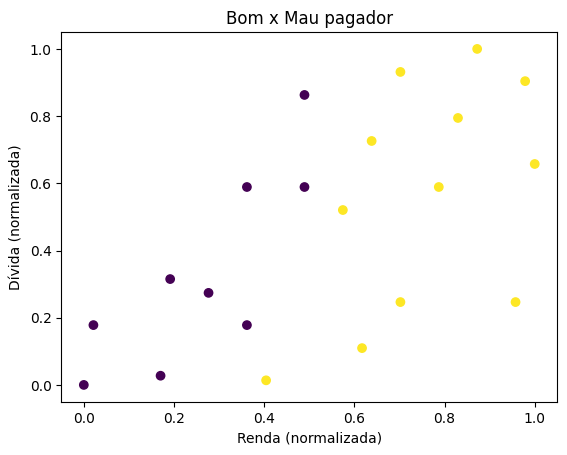

In [31]:
# plotando o gráfico para verificação se as amostras são linearmente separáveis
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Bom x Mau pagador")
plt.xlabel('Renda (normalizada)')
plt.ylabel('Dívida (normalizada)')
plt.show()

## Testes com diferentes proporções de amostras treinadas

In [32]:
# separação do dataset em amostras para treino e teste, considerando 30% dos valores para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=12)

print(X_train.shape)
print(y_train.shape)

(14, 2)
(14,)


In [33]:
p = Perceptron(random_state=42, eta0=0.0001, alpha=0.1)
p.fit(X_train, y_train)

Perceptron(alpha=0.1, eta0=0.0001, random_state=42)

In [34]:
predictions_train = p.predict(X_train) # validação do conjunto de amostras treinadas
train_score = accuracy_score(predictions_train, y_train) # avaliação de acurácia da classificação das amostras que foram apresentadas no treinamento
print("Acurácia com dados de treinamento: ", train_score)

predictions_test = p.predict(X_test) # validação do conjunto de amostras que não participaram do treinamento
test_score = accuracy_score(predictions_test, y_test) # avaliação de acurácia da classificação das amostras de teste
print("Acurácia com dados de teste: ", test_score)

print(classification_report(predictions_test, y_test))

print("Número de épocas no treinamento: ", p.n_iter_)
print("Lista de parâmetros configurados na Perceptron: ", p.get_params())

Acurácia com dados de treinamento:  0.7857142857142857
Acurácia com dados de teste:  1.0
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7

Número de épocas no treinamento:  6
Lista de parâmetros configurados na Perceptron:  {'alpha': 0.1, 'class_weight': None, 'early_stopping': False, 'eta0': 0.0001, 'fit_intercept': True, 'l1_ratio': 0.15, 'max_iter': 1000, 'n_iter_no_change': 5, 'n_jobs': None, 'penalty': None, 'random_state': 42, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


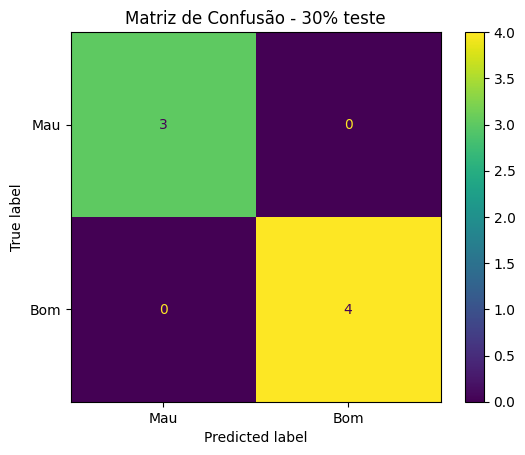

In [35]:
# Apresentação gráfica da matriz de confusão dos testes classificados (test_size = 30%)
conf_matrix = confusion_matrix(y_test, predictions_test)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Mau', 'Bom'])
cm_display.plot()
plt.title("Matriz de Confusão - 30% teste")
plt.show()

### Repetindo o experimento com test_size = 40%

In [36]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.40, random_state=12)

p2 = Perceptron(random_state=42, eta0=0.0001, alpha=0.1)
p2.fit(X_train2, y_train2)

pred_train2 = p2.predict(X_train2)
pred_test2 = p2.predict(X_test2)

print("Amostras de treino:", X_train2.shape[0], " | Amostras de teste:", X_test2.shape[0])
print("Acurácia com dados de treinamento: ", accuracy_score(pred_train2, y_train2))
print("Acurácia com dados de teste: ", accuracy_score(pred_test2, y_test2))
print(classification_report(pred_test2, y_test2))

Amostras de treino: 12  | Amostras de teste: 9
Acurácia com dados de treinamento:  1.0
Acurácia com dados de teste:  1.0
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



### Repetindo o experimento com test_size = 50%

In [37]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.50, random_state=12)

p3 = Perceptron(random_state=42, eta0=0.0001, alpha=0.1)
p3.fit(X_train3, y_train3)

pred_train3 = p3.predict(X_train3)
pred_test3 = p3.predict(X_test3)

print("Amostras de treino:", X_train3.shape[0], " | Amostras de teste:", X_test3.shape[0])
print("Acurácia com dados de treinamento: ", accuracy_score(pred_train3, y_train3))
print("Acurácia com dados de teste: ", accuracy_score(pred_test3, y_test3))
print(classification_report(pred_test3, y_test3))

Amostras de treino: 10  | Amostras de teste: 11
Acurácia com dados de treinamento:  1.0
Acurácia com dados de teste:  0.9090909090909091
              precision    recall  f1-score   support

          -1       0.83      1.00      0.91         5
           1       1.00      0.83      0.91         6

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.91        11
weighted avg       0.92      0.91      0.91        11



In [38]:
# Comparativo das acurácias obtidas nos três cenários testados
resultados = pd.DataFrame({
    "Proporção de teste": ["30%", "40%", "50%"],
    "Amostras de treino": [X_train.shape[0], X_train2.shape[0], X_train3.shape[0]],
    "Acurácia treino": [
        accuracy_score(p.predict(X_train), y_train),
        accuracy_score(pred_train2, y_train2),
        accuracy_score(pred_train3, y_train3)
    ],
    "Acurácia teste": [
        accuracy_score(predictions_test, y_test),
        accuracy_score(pred_test2, y_test2),
        accuracy_score(pred_test3, y_test3)
    ]
})
resultados

,Proporção de teste,Amostras de treino,Acurácia treino,Acurácia teste
0,30%,14,0.785714,1.000000
1,40%,12,1.000000,1.000000
2,50%,10,1.000000,0.909091


## Teste individual de novas amostras

In [39]:
# Exemplos de novas contas (Renda, Dívida) ainda não normalizadas
novas_contas = np.array([
    [2600, 600],  # perfil semelhante a "bom" pagador
    [600, 250]    # perfil semelhante a "mau" pagador
])

novas_contas_norm = scaler.transform(novas_contas)

previsoes = p.predict(novas_contas_norm)

for conta, pred in zip(novas_contas, previsoes):
    classe = "bom" if pred == 1 else "mau"
    print(f"Renda: {conta[0]}, Dívida: {conta[1]} -> Classe prevista: {classe}")

Renda: 2600, Dívida: 600 -> Classe prevista: bom
Renda: 600, Dívida: 250 -> Classe prevista: mau
